# Heart Disease UCI — Exploratory Data Analysis (EDA)

**MLOps Assignment 01 — Task 1: Data Acquisition & Exploratory Data Analysis (EDA)**

This notebook covers:
1. Data acquisition from the UCI ML Repository
2. Initial data inspection & metadata review
3. Data cleaning & preprocessing (missing values, encoding)
4. Exploratory Data Analysis with professional visualizations:
   - Histograms (feature distributions)
   - Correlation heatmap
   - Class balance / target distribution
   - Missing value analysis
   - Feature relationship analysis (vs. target, pairwise)
5. Summary of EDA findings (for the final report)

> Dataset: **Heart Disease UCI Dataset** (UCI ML Repository, id=45)


## 1. Setup & Installation

In [1]:
%pip install ucimlrepo pandas numpy matplotlib seaborn plotly scipy scikit-learn -q


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Data Acquisition

We pull the dataset directly from the UCI ML Repository using the `ucimlrepo` package.


In [3]:
from ucimlrepo import fetch_ucirepo

# Fetch dataset (id=45 -> Heart Disease)
heart_disease = fetch_ucirepo(id=45)

# Data (as pandas DataFrames)
X = heart_disease.data.features
y = heart_disease.data.targets

# Metadata & variable info
print(heart_disease.metadata)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [4]:
# Variable information: description, type, units, missing-value counts, etc.
variables_info = heart_disease.variables
variables_info


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


In [5]:
# Combine features + target into a single working dataframe
df = pd.concat([X, y], axis=1)

# Standardize target column name if needed
target_col = y.columns[0]
print(f"Target column: {target_col}")
print(f"Dataset shape: {df.shape}")
df.head()


Target column: num
Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 3. Initial Data Inspection

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [7]:
df.describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("\nUnique value counts per column:")
df.nunique().sort_values()


Duplicate rows: 0

Unique value counts per column:


,0
sex,2
fbs,2
exang,2
restecg,3
slope,3
thal,3
ca,4
cp,4
num,5
oldpeak,40


## 4. Target Variable Understanding

The raw `num` target in this dataset is **multi-class** (0 = no disease, 1–4 = increasing
severity of heart disease). For this assignment we convert it into a **binary classification
target**: `0` = no disease, `1` = presence of disease (any of 1–4), which matches the
"binary target (presence/absence of heart disease)" requirement.


In [9]:
print("Original target value counts:")
print(df[target_col].value_counts().sort_index())

# Create binary target
df["target"] = (df[target_col] > 0).astype(int)

print("\nBinary target value counts:")
print(df["target"].value_counts())


Original target value counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target value counts:
target
0    164
1    139
Name: count, dtype: int64


## 5. Missing Value Analysis

In [10]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_pct
ca,4,1.32
thal,2,0.66


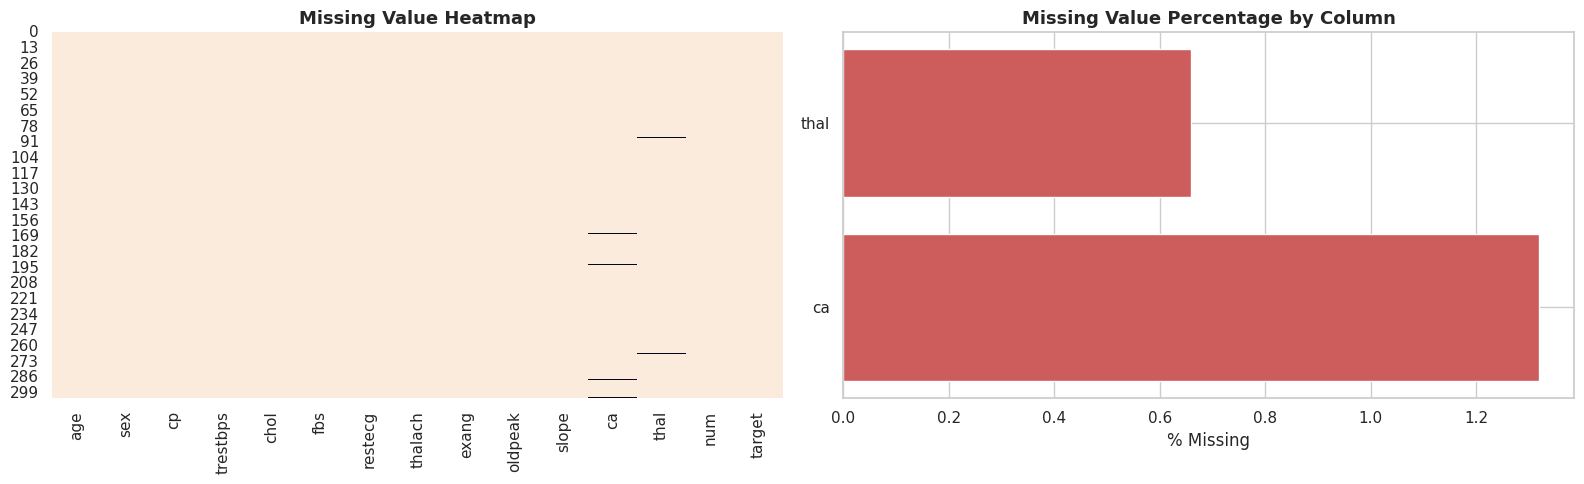

In [11]:
# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap of missingness
sns.heatmap(df.isnull(), cbar=False, cmap="rocket_r", ax=axes[0])
axes[0].set_title("Missing Value Heatmap")

# Bar chart of missing percentage
missing_nonzero = missing_summary[missing_summary["missing_count"] > 0]
if len(missing_nonzero) > 0:
    axes[1].barh(missing_nonzero.index, missing_nonzero["missing_pct"], color="indianred")
    axes[1].set_xlabel("% Missing")
    axes[1].set_title("Missing Value Percentage by Column")
else:
    axes[1].text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=14)
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


## 6. Data Cleaning & Preprocessing

Steps:
1. Handle missing values (impute using median for numeric / mode for categorical).
2. Encode categorical features appropriately.
3. Keep a clean, reproducible dataframe (`df_clean`) ready for feature engineering.


In [12]:
df_clean = df.drop(columns=[target_col]).copy()  # drop original multi-class target, keep binary 'target'

# Identify column types based on the UCI metadata / domain knowledge
# ca and thal are known to have missing values in this dataset
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

numeric_cols = [c for c in numeric_cols if c in df_clean.columns]
categorical_cols = [c for c in categorical_cols if c in df_clean.columns]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [13]:
# Impute missing values
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Imputed '{col}' missing values with median = {median_val}")

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"Imputed '{col}' missing values with mode = {mode_val}")

print("\nRemaining missing values after imputation:", df_clean.isnull().sum().sum())


Imputed 'ca' missing values with mode = 0.0
Imputed 'thal' missing values with mode = 3.0

Remaining missing values after imputation: 0


In [14]:
# Cast categorical columns to integer category codes (already numeric-coded in this dataset)
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(int)

df_clean["target"] = df["target"]

df_clean.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [15]:
# Human-readable mapping (for EDA/plot labels only — not used in modeling)
sex_map = {1: "Male", 0: "Female"}
cp_map = {1: "Typical Angina", 2: "Atypical Angina", 3: "Non-anginal Pain", 4: "Asymptomatic"}
target_map = {0: "No Disease", 1: "Disease"}

df_display = df_clean.copy()
df_display["sex_label"] = df_display["sex"].map(sex_map)
df_display["cp_label"] = df_display["cp"].map(cp_map)
df_display["target_label"] = df_display["target"].map(target_map)

df_display.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_label,cp_label,target_label
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0,Male,Typical Angina,No Disease
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1,Male,Asymptomatic,Disease
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1,Male,Asymptomatic,Disease
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0,Male,Non-anginal Pain,No Disease
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0,Female,Atypical Angina,No Disease


## 7. Class Balance / Target Distribution

Understanding class balance is essential — it informs metric choice (e.g. relying on
accuracy alone can be misleading for imbalanced classes) and whether techniques like
class weighting or resampling (SMOTE) are needed later.


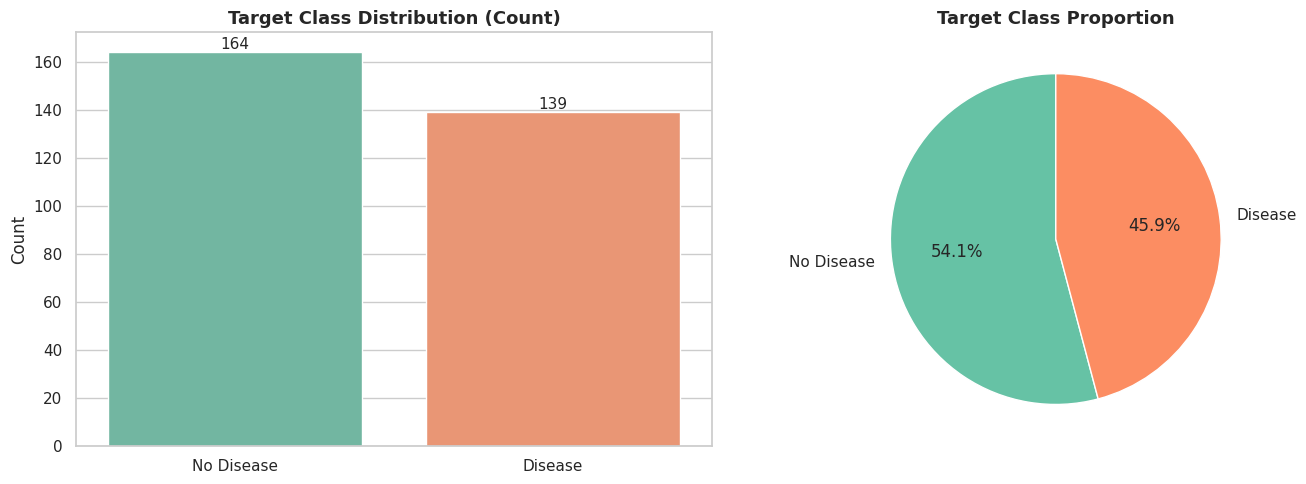

target_label
No Disease    54.1
Disease       45.9
Name: proportion, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="target_label", data=df_display, ax=axes[0], palette="Set2")
axes[0].set_title("Target Class Distribution (Count)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                      ha="center", va="bottom", fontsize=11)

# Pie chart
class_counts = df_display["target_label"].value_counts()
axes[1].pie(class_counts, labels=class_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"), startangle=90,
            wedgeprops={"edgecolor": "white"})
axes[1].set_title("Target Class Proportion")

plt.tight_layout()
plt.show()

print(df_display["target_label"].value_counts(normalize=True).round(3) * 100)


## 8. Histograms — Feature Distributions

Distributions of numeric features, split where useful, to spot skew, outliers, and
scaling needs before modeling.


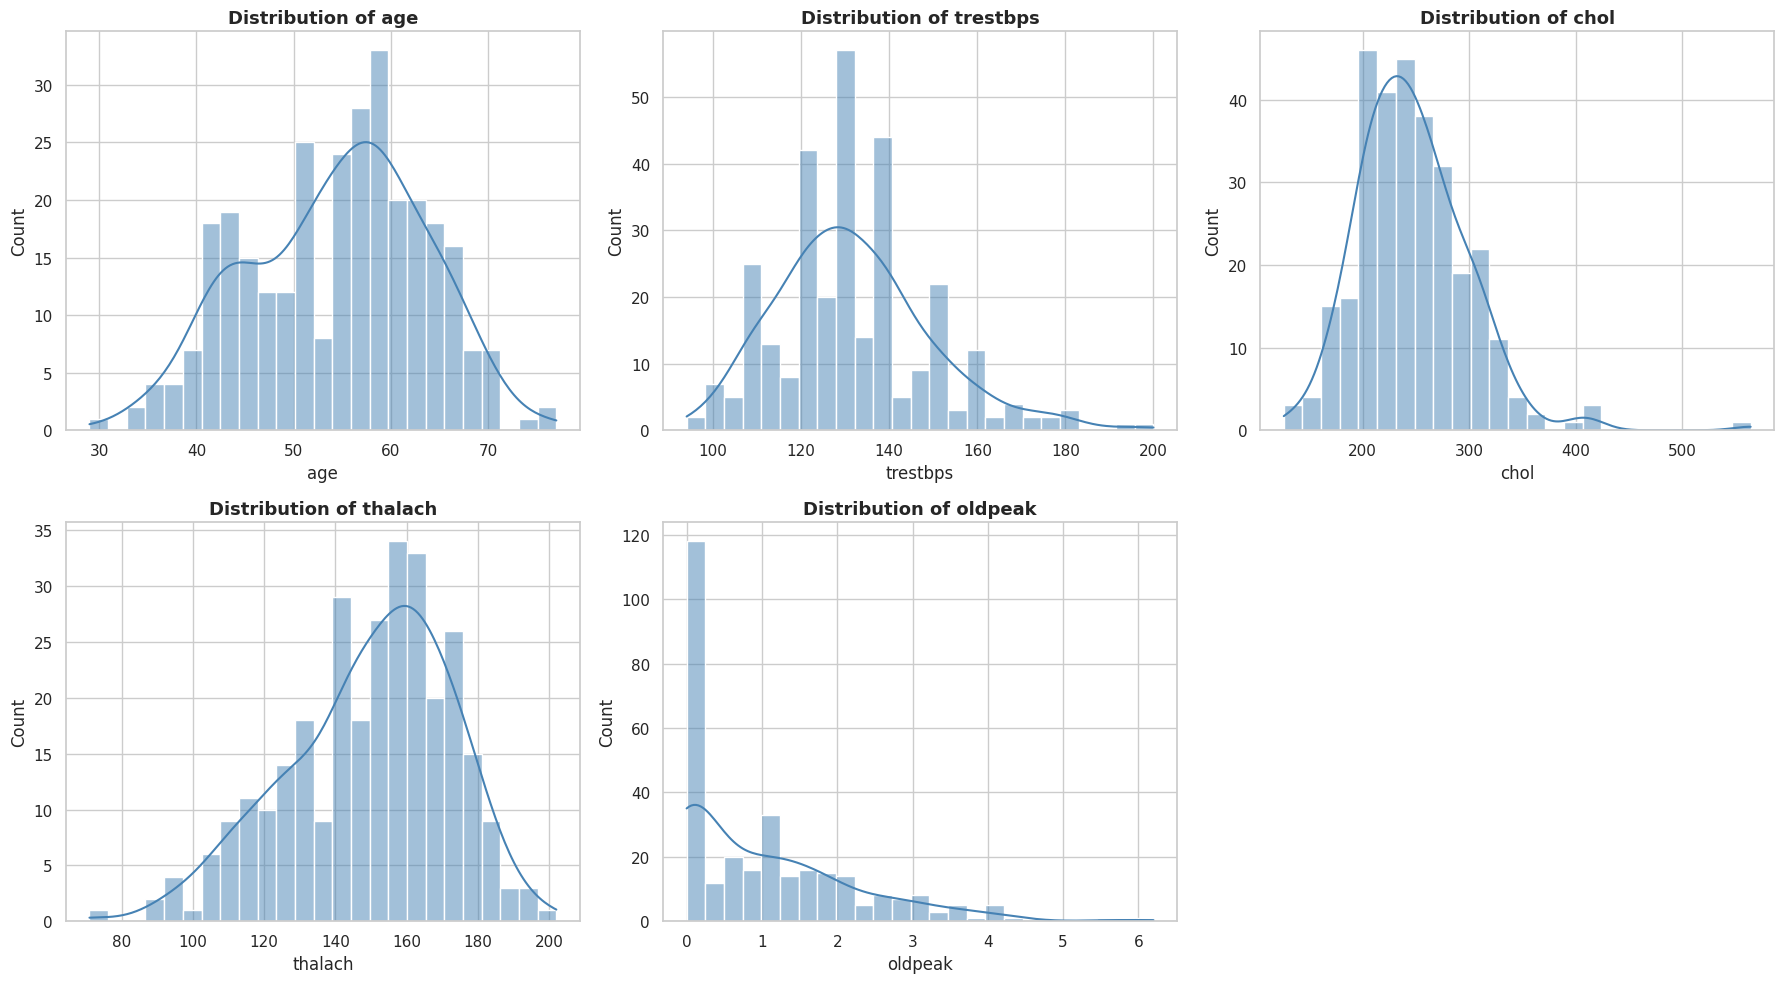

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_display[col], kde=True, ax=axes[i], color="steelblue", bins=25)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)

# Hide any unused subplot
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()


In [18]:
# Interactive version with Plotly (optional, nicer for reports)
for col in numeric_cols:
    fig = px.histogram(df_display, x=col, color="target_label", marginal="box",
                        nbins=30, opacity=0.7,
                        title=f"Distribution of {col} by Target Class",
                        color_discrete_sequence=px.colors.qualitative.Set2)
    fig.update_layout(bargap=0.05, template="plotly_white")
    fig.show()


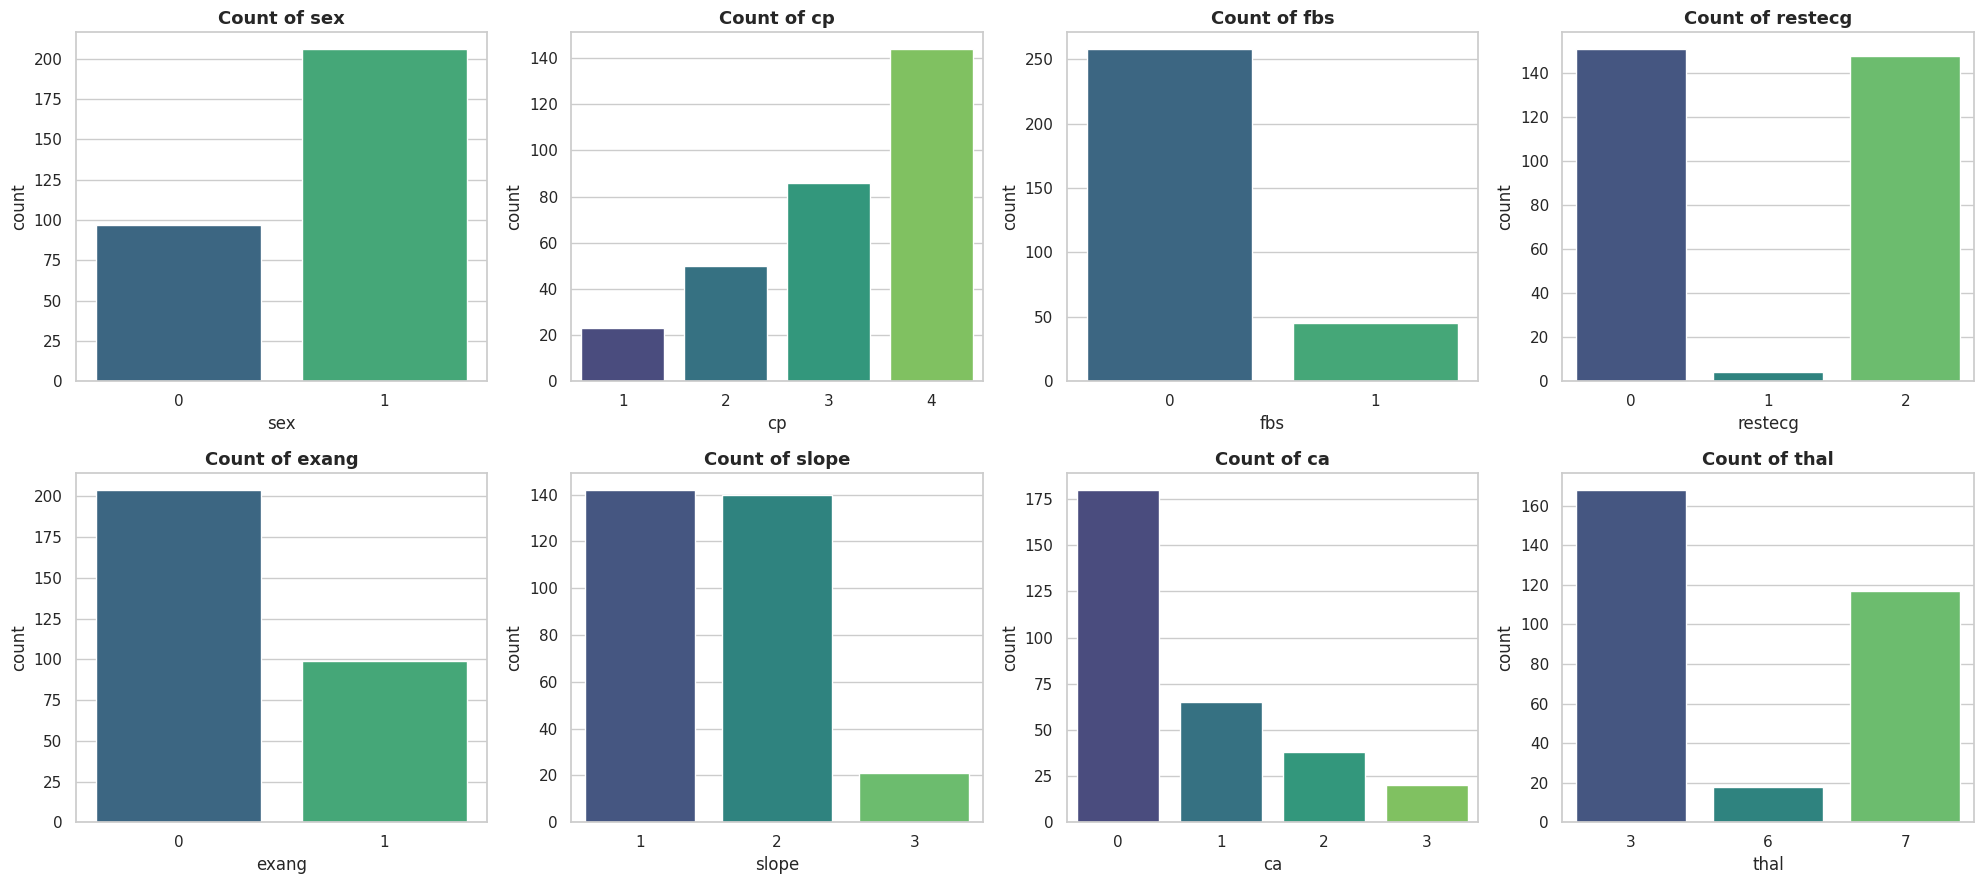

In [19]:
# Categorical feature counts
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df_display, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Count of {col}")

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()


## 9. Outlier Detection (Boxplots)

Boxplots highlight potential outliers in continuous features that may need capping/
transformation during feature engineering.


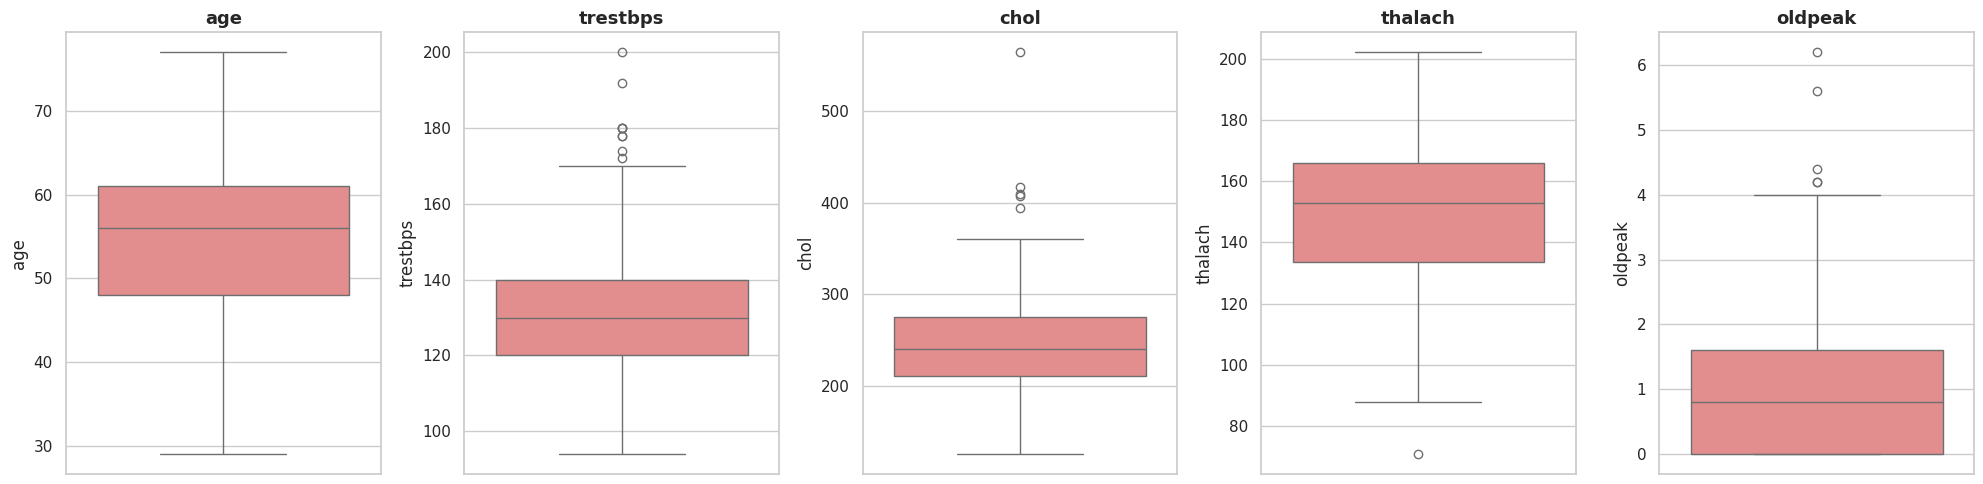

In [20]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4*len(numeric_cols), 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_display[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


## 10. Correlation Heatmap

Pairwise correlations between numeric/encoded features help identify multicollinearity
and features most associated with the target.


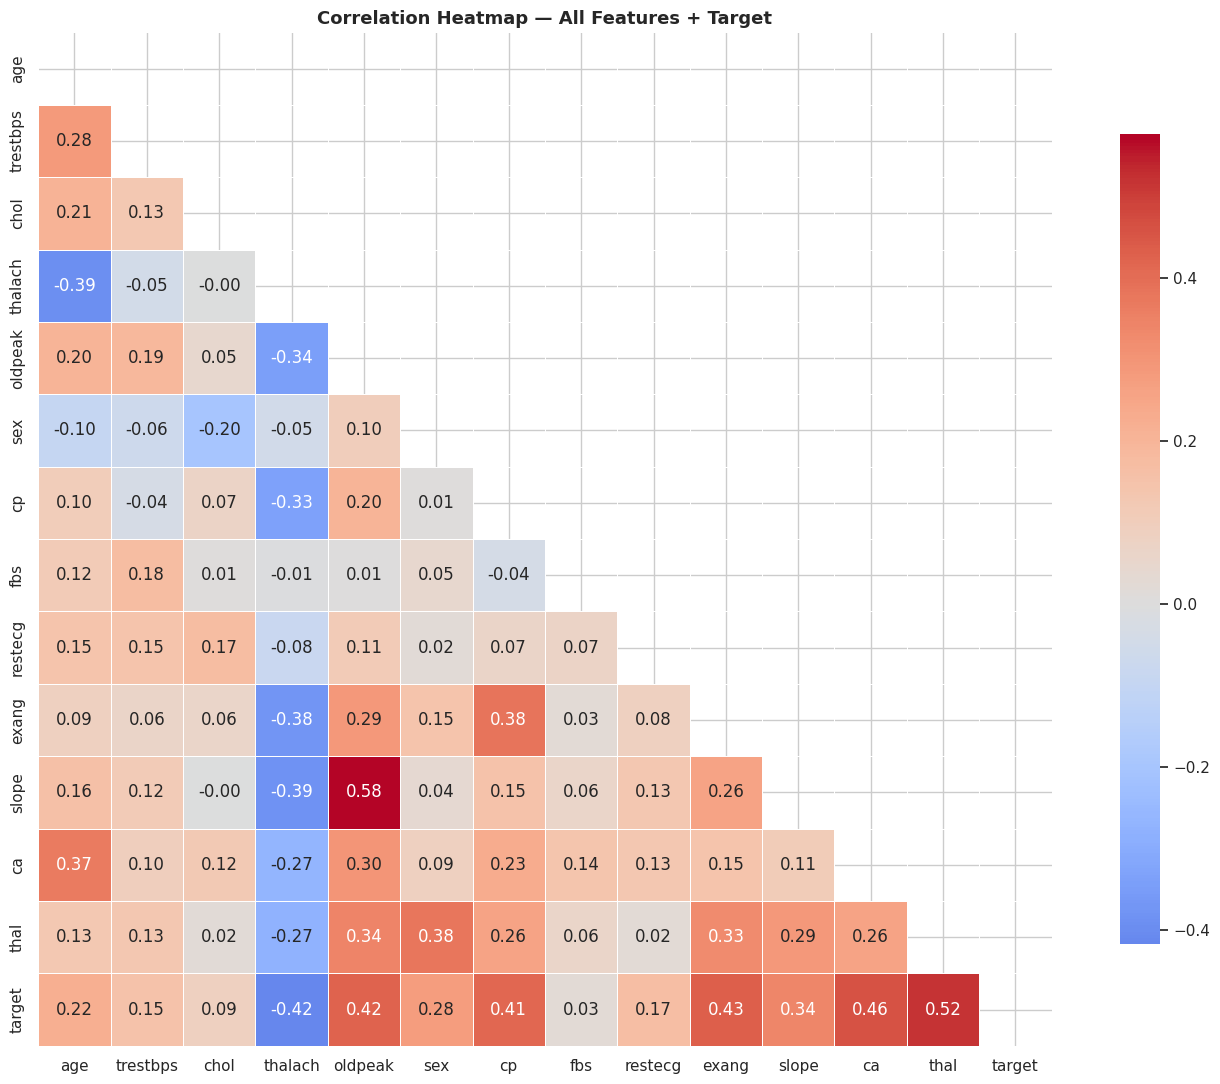

In [21]:
corr_cols = numeric_cols + categorical_cols + ["target"]
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — All Features + Target")
plt.tight_layout()
plt.show()


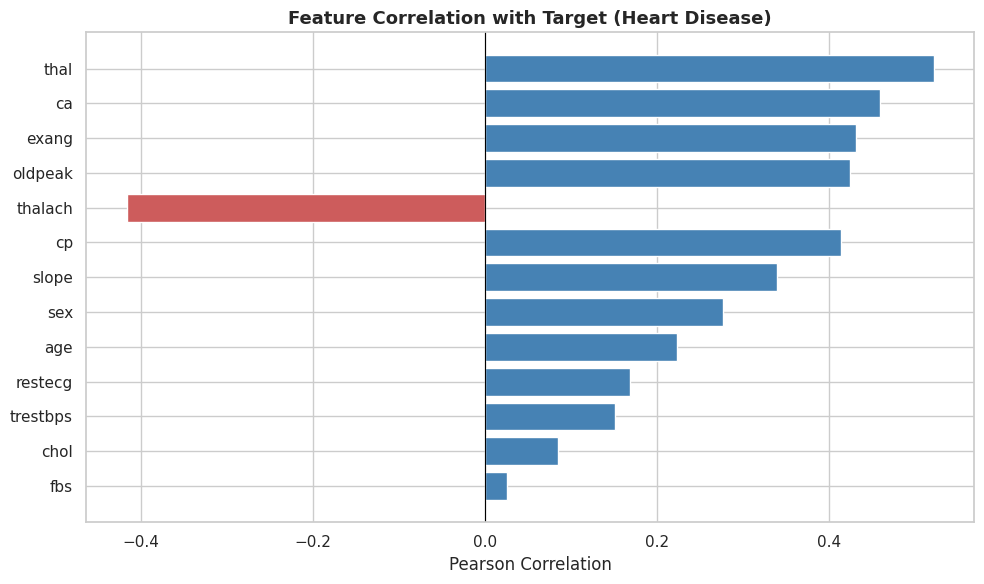

,target
thal,0.522057
ca,0.460033
exang,0.431894
oldpeak,0.424510
thalach,-0.417167
cp,0.414446
slope,0.339213
sex,0.276816
age,0.223120
restecg,0.169202


In [22]:
# Features most correlated with target, ranked
target_corr = corr_matrix["target"].drop("target").sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ["indianred" if v < 0 else "steelblue" for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Target (Heart Disease)")
plt.xlabel("Pearson Correlation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

target_corr


## 11. Feature Relationship Analysis (vs. Target)

Deeper look at how key features relate to the presence of heart disease.


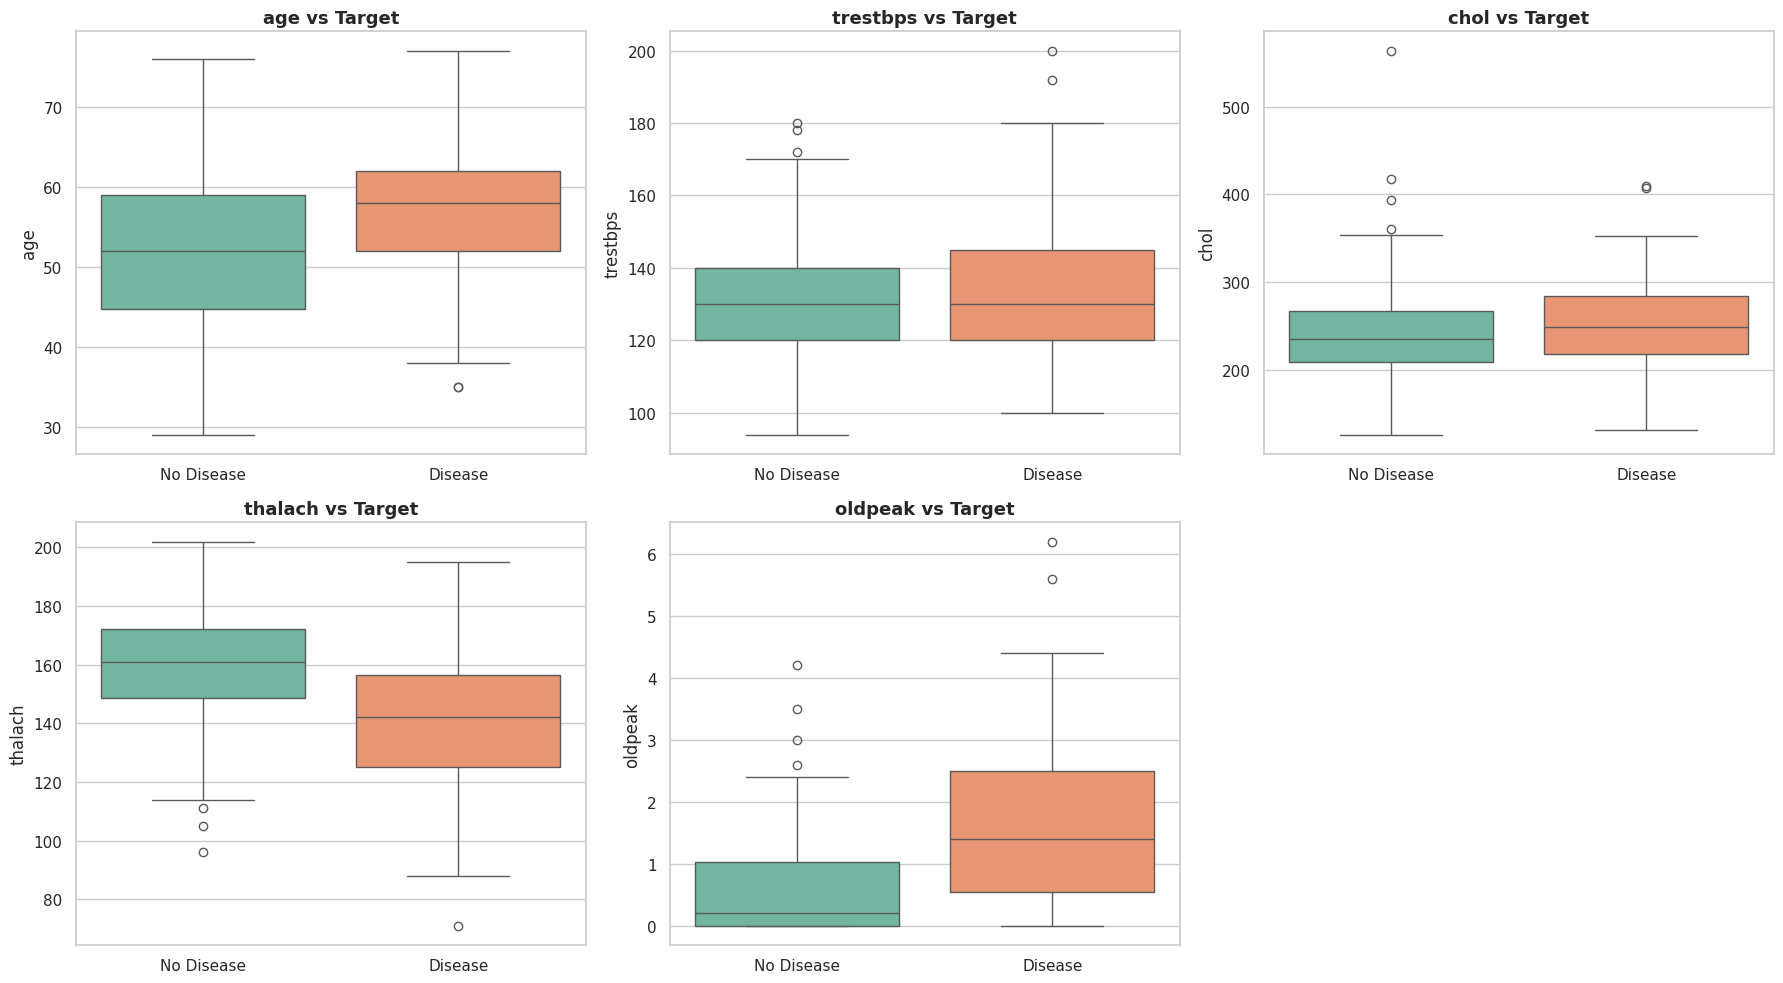

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x="target_label", y=col, data=df_display, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs Target")
    axes[i].set_xlabel("")

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()


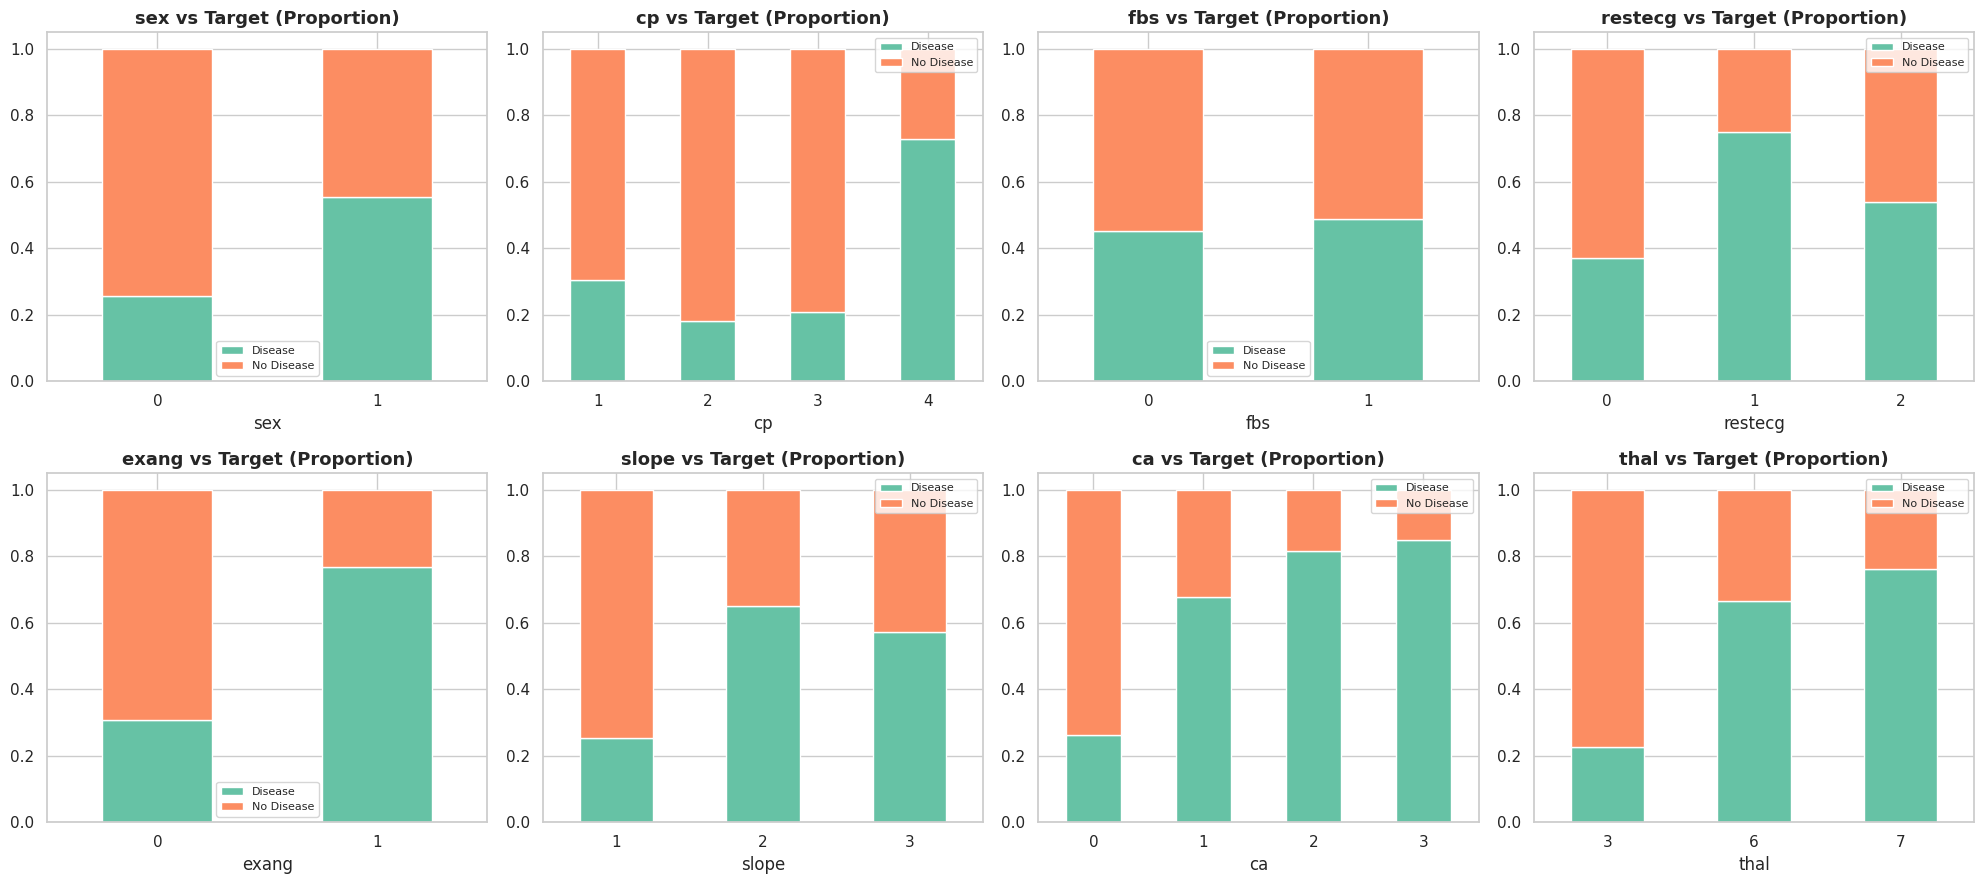

In [24]:
# Categorical features vs target (proportion stacked bars)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df_display[col], df_display["target_label"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=sns.color_palette("Set2"))
    axes[i].set_title(f"{col} vs Target (Proportion)")
    axes[i].set_xlabel(col)
    axes[i].legend(title="", fontsize=8)
    axes[i].tick_params(axis="x", rotation=0)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()


In [25]:
# Sex vs Chest Pain Type vs Target - example multi-way relationship
fig = px.sunburst(df_display, path=["sex_label", "cp_label", "target_label"],
                   title="Sex → Chest Pain Type → Target Class Breakdown",
                   color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(template="plotly_white")
fig.show()


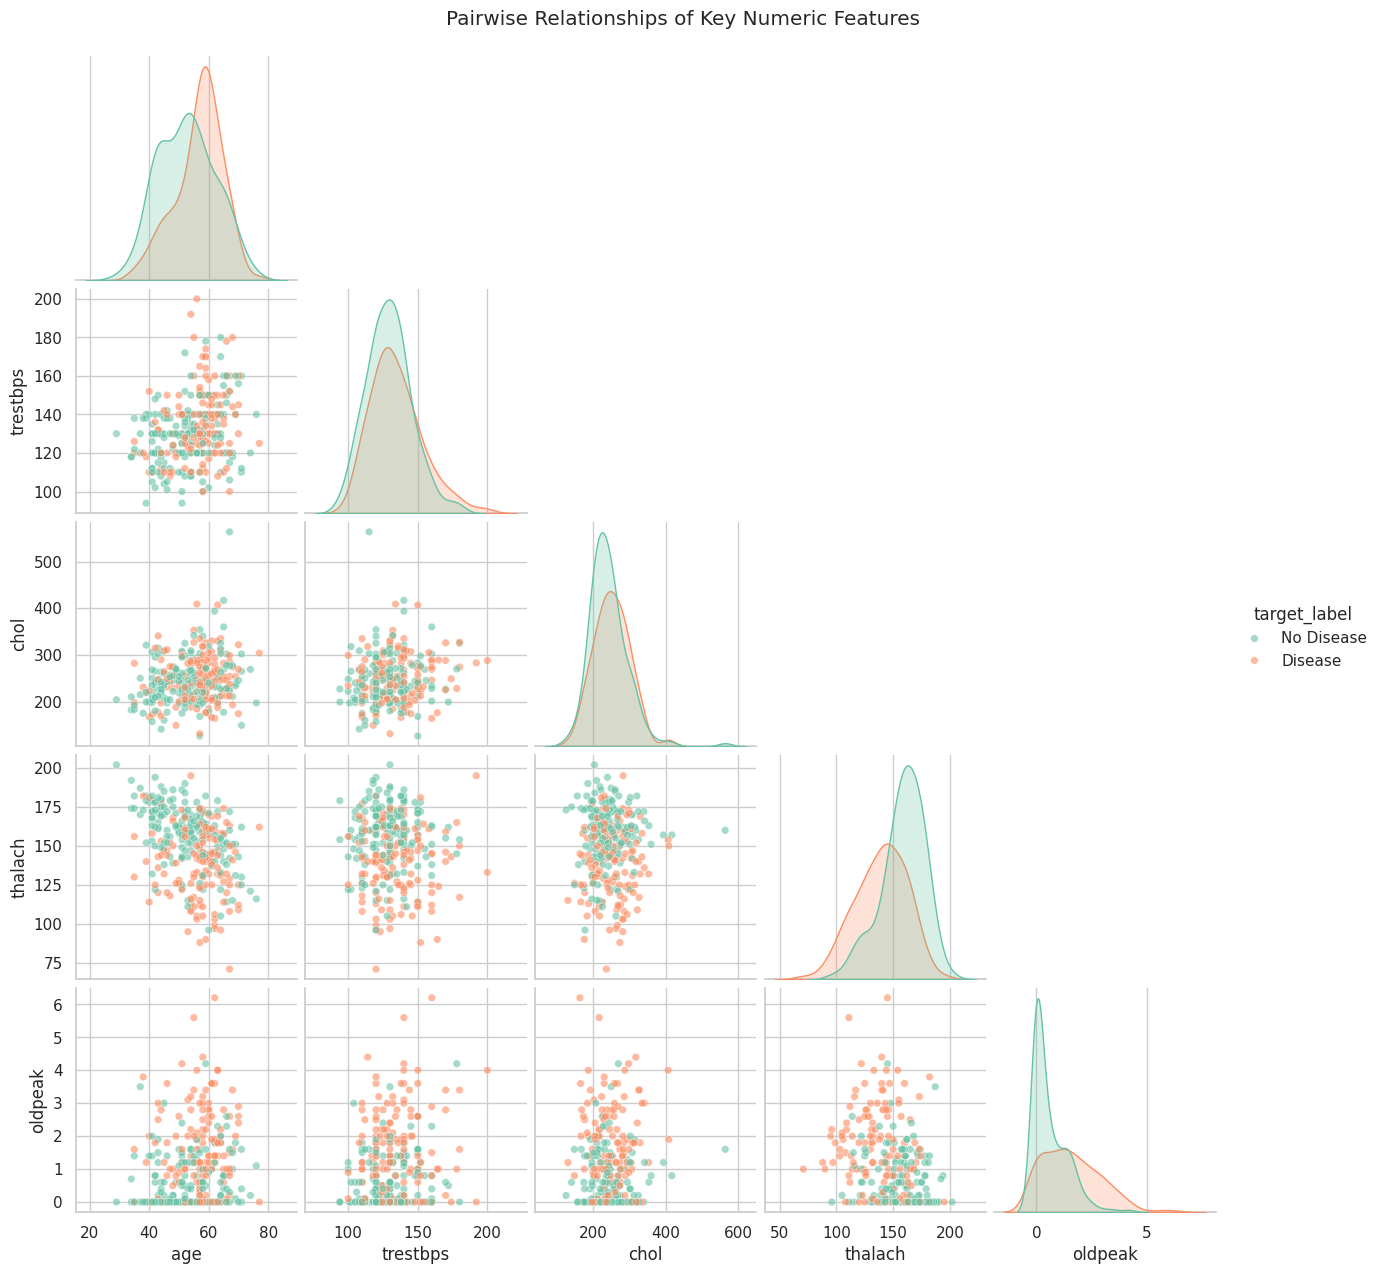

In [26]:
# Pairplot of key numeric features colored by target
key_features = ["age", "trestbps", "chol", "thalach", "oldpeak", "target_label"]
sns.pairplot(df_display[key_features], hue="target_label", palette="Set2",
             diag_kind="kde", corner=True, plot_kws={"alpha": 0.6, "s": 30})
plt.suptitle("Pairwise Relationships of Key Numeric Features", y=1.02)
plt.show()


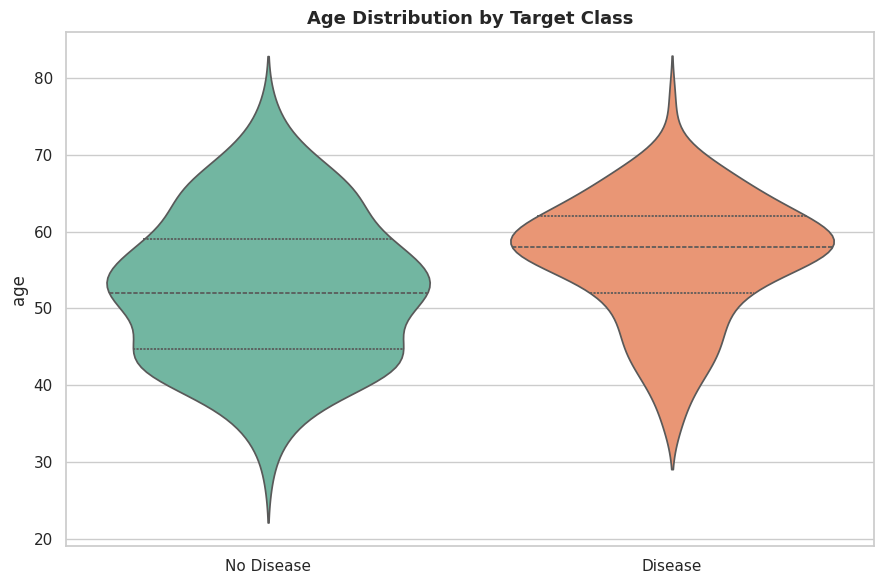

In [27]:
# Age distribution by target (violin plot)
plt.figure(figsize=(9, 6))
sns.violinplot(x="target_label", y="age", data=df_display, palette="Set2", inner="quartile")
plt.title("Age Distribution by Target Class")
plt.xlabel("")
plt.tight_layout()
plt.show()


## 12. Skewness & Statistical Summary

Quantifying skewness helps decide whether log/power transforms are needed during
feature engineering.


In [28]:
from scipy.stats import skew, kurtosis

stats_summary = pd.DataFrame({
    "mean": df_clean[numeric_cols].mean(),
    "median": df_clean[numeric_cols].median(),
    "std": df_clean[numeric_cols].std(),
    "skewness": df_clean[numeric_cols].apply(skew),
    "kurtosis": df_clean[numeric_cols].apply(kurtosis),
}).round(3)

stats_summary


,mean,median,std,skewness,kurtosis
age,54.439,56.0,9.039,-0.208,-0.535
trestbps,131.690,130.0,17.600,0.703,0.846
chol,246.693,241.0,51.777,1.130,4.398
thalach,149.607,153.0,22.875,-0.535,-0.072
oldpeak,1.040,0.8,1.161,1.263,1.530


## 13. Save Cleaned Dataset

Persist the cleaned dataframe so downstream notebooks (feature engineering, model
training) can load it directly without repeating the cleaning steps.


In [29]:
import os

os.makedirs("data", exist_ok=True)
df_clean.to_csv("data/heart_disease_clean.csv", index=False)
print("Saved cleaned dataset to data/heart_disease_clean.csv")
print("Shape:", df_clean.shape)


Saved cleaned dataset to data/heart_disease_clean.csv
Shape: (303, 14)


## 14. EDA Summary (Key Findings)

Based on the outputs generated above, here are the key findings from this EDA:

**Class balance:**
The binary target is reasonably balanced: **164 patients (54.1%) with no disease** vs.
**139 patients (45.9%) with disease present** (from the original multi-class breakdown:
0 → 164, 1 → 55, 2 → 36, 3 → 35, 4 → 13). This is close enough to a 50/50 split that
**accuracy is a reasonably safe metric**, though precision, recall, F1, and ROC-AUC should
still be reported for a fuller picture, as recommended in the assignment FAQs.

**Missing values:**
Only two columns had missing data, both minor: **`ca` (4 missing, 1.32%)** and
**`thal` (2 missing, 0.66%)**. Both are categorical/ordinal features, so missing values
were imputed using the **column mode**, and numeric columns (none were missing here) were
set up to use **median imputation** if needed. No rows were dropped, preserving the full
303-patient sample.

**Top features correlated with the target:**
Ranked by absolute Pearson correlation with the binary target:
1. `thal` (thalassemia) — **0.52**
2. `ca` (number of major vessels colored by fluoroscopy) — **0.46**
3. `exang` (exercise-induced angina) — **0.43**
4. `oldpeak` (ST depression induced by exercise) — **0.42**
5. `thalach` (max heart rate achieved) — **−0.42**
6. `cp` (chest pain type) — **0.41**
7. `slope` (slope of peak exercise ST segment) — **0.34**
8. `sex` — **0.28**
9. `age` — **0.22**

`restecg`, `trestbps` show weak correlation (~0.15–0.17), while **`chol` (0.085) and
`fbs` (0.025) are essentially uncorrelated with the target** in this dataset — a useful
(if counterintuitive) finding, since cholesterol is often assumed to be a strong heart
disease indicator on its own.

**Outliers:**
Boxplots show visible outliers in **`chol`** (a few very high values, consistent with its
high kurtosis of 4.4) and **`trestbps`** (resting blood pressure), with a handful of
patients recording unusually high readings. **`oldpeak`** is right-skewed with a cluster
of higher values that also show up as outliers on the boxplot. These should be reviewed
during feature engineering — capping/winsorizing or a log/sqrt transform are reasonable
options rather than removing rows outright.

**Distribution shape (skewness):**
| Feature | Skewness | Interpretation |
|---|---|---|
| `age` | −0.21 | Roughly symmetric, slight left skew |
| `trestbps` | 0.70 | Moderate right skew |
| `chol` | 1.13 | Strong right skew — long tail of high cholesterol values |
| `thalach` | −0.54 | Mild left skew |
| `oldpeak` | 1.26 | Strong right skew — most patients have low ST depression, a few much higher |

`chol` and `oldpeak` are the best candidates for a log or Box-Cox style transform before
modeling, since both are notably right-skewed with heavier tails (also reflected in their
higher kurtosis values).

**Categorical patterns vs. target:**
From the stacked bar charts and sunburst plot:
- **`sex`**: male patients have a noticeably higher rate of disease presence than female patients.
- **`cp` (chest pain type)**: patients with **asymptomatic chest pain** show the highest
  proportion of disease, which is somewhat counterintuitive — asymptomatic doesn't mean
  low risk in this dataset — while typical anginal pain is more associated with no disease.
- **`exang` (exercise-induced angina)**: presence of exercise-induced angina is strongly
  associated with disease presence, consistent with it being one of the top correlated features.
- **`slope`**: a flat/downsloping ST segment slope is associated with higher disease rates
  compared to an upsloping segment.

**Implications for feature engineering / modeling:**
- `thal`, `ca`, `exang`, `oldpeak`, `thalach`, and `cp` look like the strongest predictive
  features and should be prioritized/inspected closely during feature engineering.
- `chol` and `fbs` may contribute little on their own but could still be kept for
  interaction effects or dropped after a feature-importance check with the trained models.
- `chol` and `oldpeak` are good candidates for a log transform given their skew.
- Categorical features (`sex`, `cp`, `slope`, etc.) should be one-hot or ordinal encoded
  depending on the model (tree-based models can use ordinal/integer codes directly; logistic
  regression will likely benefit from one-hot encoding for nominal categories like `cp`).
- Given the near-balanced classes, standard train/test stratified splitting on `target`
  should be sufficient — no resampling (e.g. SMOTE) appears necessary.
